In [1]:
#!pip install networkx

In [2]:
# ==============================
# IMPORT LIBRARIES
# ==============================
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
# ==============================
# GRAPH CLASS
# ==============================
class Graph:
    def __init__(self, V):
        self.V = V
        self.adj = {i: [] for i in range(V)}

    def add_edge(self, u, v):
        self.adj[u].append(v)

    # ==============================
    # BFS
    # ==============================
    def bfs(self, start):
        visited = [False] * self.V
        queue = deque([start])
        visited[start] = True

        result = []

        while queue:
            node = queue.popleft()
            result.append(node)

            for neighbor in self.adj[node]:
                if not visited[neighbor]:
                    visited[neighbor] = True
                    queue.append(neighbor)

        return result

    # ==============================
    # DFS
    # ==============================
    def dfs_util(self, node, visited, result):
        visited[node] = True
        result.append(node)

        for neighbor in self.adj[node]:
            if not visited[neighbor]:
                self.dfs_util(neighbor, visited, result)

    def dfs(self, start):
        visited = [False] * self.V
        result = []
        self.dfs_util(start, visited, result)
        return result

In [4]:
# ==============================
# USER INPUT
# ==============================
V = int(input("Enter number of vertices: "))
E = int(input("Enter number of edges: "))

g = Graph(V)

print("Enter edges (u v):")
edges = []
for _ in range(E):
    u, v = map(int, input().split())
    g.add_edge(u, v)
    edges.append((u, v))

start = int(input("Enter starting node: "))

Enter number of vertices: 6
Enter number of edges: 7
Enter edges (u v):
0 1
0 2
1 3
1 4
2 4
3 5
4 5
Enter starting node: 0


In [5]:
# ==============================
# RUN BFS & DFS
# ==============================
bfs_result = g.bfs(start)
dfs_result = g.dfs(start)

print("\nBFS Traversal:", bfs_result)
print("DFS Traversal:", dfs_result)


BFS Traversal: [0, 1, 2, 3, 4, 5]
DFS Traversal: [0, 1, 3, 5, 4, 2]


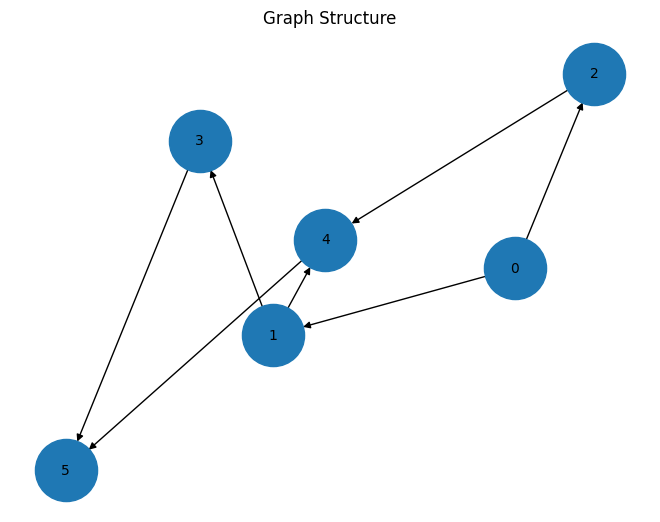

In [6]:
# ==============================
# GRAPH VISUALIZATION
# ==============================
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure()
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10)
plt.title("Graph Structure")
plt.show()

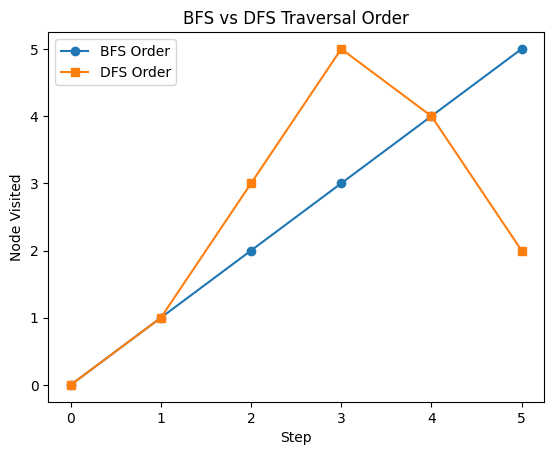

In [7]:
# ==============================
# BFS vs DFS COMPARISON GRAPH
# ==============================
plt.figure()

plt.plot(bfs_result, marker='o', label="BFS Order")
plt.plot(dfs_result, marker='s', label="DFS Order")

plt.xlabel("Step")
plt.ylabel("Node Visited")
plt.title("BFS vs DFS Traversal Order")
plt.legend()

plt.show()